# Assignment 4
### Do three of four.

### Exercise 1: Contingent Comparisons
- Load the Minnesota use of force data.
- Bootstrap the proportion of missing values for `subject_injury` for each race, and plot the results with grouped KDE and ECDF plots
- Describe what you see. When we consider second order uncertainty, how similar or different are the sampling distributions of these proportions? 

In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('data/mn_police_use_of_force.csv')

# 2. Create the missing value indicator (True if missing, False if not)
df['subject_injury_missing'] = df['subject_injury'].isna()


In [10]:

# 3. Define the statistic (Proportion is just the mean of a boolean array)
def stat(x):
    return np.mean(x)

# 4. Define the Bootstrap Function
def simulate(data, stat_func, S=1000):
    estimates = []
    n = len(data)
    # Using numpy for speed, but pandas .sample(frac=1, replace=True) works too
    for s in range(S):
        resample = np.random.choice(data, size=n, replace=True)
        estimates.append(stat_func(resample))
    return np.array(estimates)

# 5. Run Bootstrap for each Race
results = {}
races = df['race'].dropna().unique()

for race in races:
    race_data = df[df['race'] == race]['subject_injury_missing']
    results[race] = simulate(race_data, stat, S=1000)


C:\Users\osegh\AppData\Local\Temp\ipykernel_19264\538022360.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(estimates, label=race)


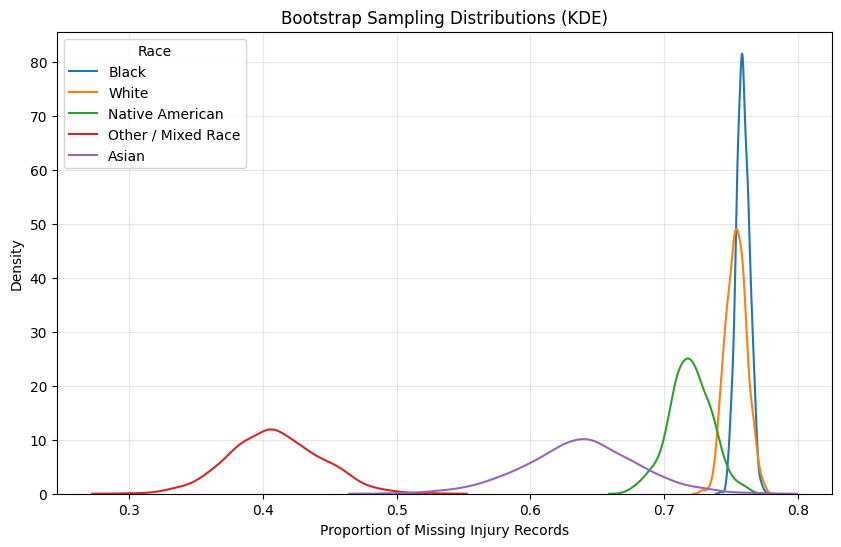

In [11]:
plt.figure(figsize=(10, 6))

# Plot KDE for each race
for race, estimates in results.items():
    sns.kdeplot(estimates, label=race)

plt.title('Bootstrap Sampling Distributions (KDE)')
plt.xlabel('Proportion of Missing Injury Records')
plt.ylabel('Density')
plt.legend(title='Race')
plt.grid(True, alpha=0.3)
plt.show()

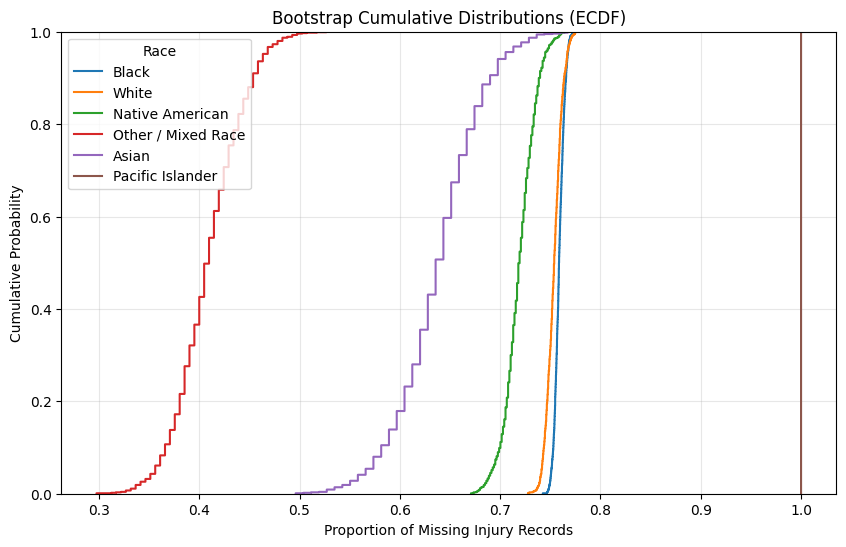

In [12]:
plt.figure(figsize=(10, 6))

for race, estimates in results.items():
    sns.ecdfplot(estimates, label=race)

plt.title('Bootstrap Cumulative Distributions (ECDF)')
plt.xlabel('Proportion of Missing Injury Records')
plt.ylabel('Cumulative Probability')
plt.legend(title='Race')
plt.grid(True, alpha=0.3)
plt.show()

Analysis

- In the KDE for White and Black races are very tall and narrow while the distributions for Asian, Native American or Other are much shorter and wider.
- When considering second order uncertainty, the sampling distributions are different. 
    - The sample size impact for the Black and White categories have a much higher sample size in this dataset compared to Asian, Native American or Other.
    - Because the variance of a sampling distribution scales with 1/sqrt{N}, the groups with larger sample sizes have much tighter confidence intervals (less uncertainty).
    - While the simple average of missing data might look similar across some races, I am less confident in the true proportion for the minority groups because their sampling distributions are so wide. We cannot rule out extreme values for the smaller groups as easily as we can for the larger groups. 

### Exercise 2: Invitation to Inference
- Run the simulation code line by line and comment what each line is doing, or write your own code to do the resampling
- Open the NHANES or Ames prices or College Completion data. Pick a variable and a statistic to compute (e.g. mean, median, variance, IQR)
- Use the `simulate` function from class to get a sample of estimates for your statistic and your data
- Create a new function, `interval(L,H,estimates)`, that computes the $L$-th and $H$-th quantiles for your estimates, $H>L$
- If $L=.05$ and $H=.95$, this is a **90-percent confidence interval**: "For our statistic, this interval captures the true value of the population parameter 90 percent of the time. (We are 90% **confident** that it includes the true value of the parameter, but the probability that the true parameter lies in this interval is 0 or 1.)"
- We will spend much more time on this later in class, but for people who have done hypothesis testing before, you now know how to do it directly from the data: No central limit theorem required.

In [18]:
# 1. Load the Data
# We read the CSV file into a pandas DataFrame.
df = pd.read_csv('data/college_completion.csv')


In [19]:
def stat(x):
    stat = np.mean(x)
    return stat

In [20]:
def simulate(df_var, df, fcn, S=1000, plot=True):
    ''' Bootstrap simulation code. '''    
    x = df[df_var]

    estimates = []
    for s in range(S):
        # Draw a new sample, with replacement:
        x_s = x.sample(frac=1.0,replace=True)
        # Compute statistic:
        stat_s = fcn(x_s)
        # Append estimate:
        estimates.append(stat_s)
    estimates = np.array(estimates) # Convert estimates list to numpy array

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # 1 row, 2 columns
        sns.kdeplot(x, ax = axes[0]).set(title='KDE of Underlying Data')
        sns.kdeplot(estimates, ax = axes[1]).set(title='KDE of Computed Statistics')
        axes[1].axvline(x=fcn(x), color='orange', linestyle='--')
        sns.ecdfplot(estimates, ax = axes[2]).set(title='ECDF of Computed Statistics')
        axes[2].axvline(x=fcn(x), color='orange', linestyle='--')
        plt.show()
        print(f'Variance of estimates is: {np.var(estimates)}')
        
    return estimates


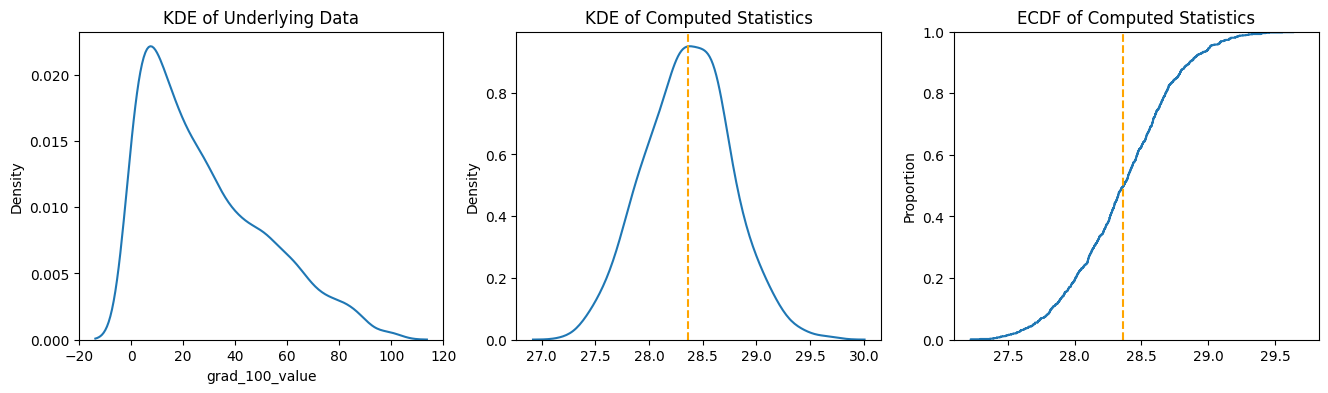

Variance of estimates is: 0.15993173485580026


In [ ]:
# I chose the variable 'grad_100_value' (graduation rate). 
df_var = 'grad_100_value'
estimates = simulate(df_var, df, stat)

In [23]:
def interval(L, H, estimates):
    
    lower_bound = np.quantile(estimates, L)
    upper_bound = np.quantile(estimates, H)
    return lower_bound, upper_bound

conf_interval = interval(0.05, 0.95, estimates)

conf_interval

(np.float64(27.698852375238854), np.float64(29.012781418024396))

We are 90% confident that the true population mean for graduation rates falls between 27.7% and 29.0%. This interval was constructed purely from the data using resampling, without assuming a normal distribution or using the Central Limit Theorem.

### Exercise 3: Intro to A/B Testing
- Go here, and read about this study: https://www.clinicaltrials.gov/study/NCT01985360
- Read the Study Overview and explain what the goal of the trial is 
- Read the Study Plan and explain how it was designed and why -- there's lots of medical jargon, but the main point is how patients were assigned to interventions. 
- Read the Results Posted: Go to **Outcome Measures**. Explain how table 1 ("Incidence of Death from Any Cause or Myocardial Infarction") is a contingency table. These are the data for this exercise.
- What is the difference in surival rates between the invasive strategy and the conservative strategy?
- Bootstrap the survival rates for the two groups, and plot them as KDEs and ECDFs against one another
- Bootstrap the difference in surival rates, and plot it as a KDE and ECDF
- Is this an effective health intervention? Explain your answer clearly

This would be what CS people call **A/B testing** and everyone else called a **randomized controlled trial**: Using randomized assignment to detect the difference in outcomes between two groups. (We've just done a non-parametric version of a two-sample t-test.)

1. Goal of the Trial: The goal of the ISCHEMIA-CKD trial was to determine if an invasive strategy was better than a conservative strategy for reducing the risk of death or heart attack (myocardial infarction) in high-risk patients who have both advanced Chronic Kidney Disease (CKD) and stable ischemic heart disease.

2. Study Design:

    - Design: This was a Randomized Controlled Trial (RCT), often called an "A/B Test" in data science.

    - Assignment: Patients were randomly assigned (1:1 ratio) to either the Invasive group or the Conservative group.

    - Randomization ensures that both groups are similar in every way except for the treatment they receive. This eliminates confounding variables, allowing researchers to conclude that any difference in outcomes is caused by the treatment itself.

| Group | Total Patients (N) | Had Event (Death/MI) | Did Not Have Event ("Survived") |
| :--- | :--- | :--- | :--- |
| **Invasive (Group A)** | 388 | 123 | 265 |
| **Conservative (Group B)** | 389 | 129 | 260 |

In [26]:
# Invasive Group: 388 Total, 123 Events -> 265 Survived
data_invasive = np.array([1]*265 + [0]*123)

# Conservative Group: 389 Total, 129 Events -> 260 Survived
data_conservative = np.array([1]*260 + [0]*129)

# 2. Define Statistic
def stat_mean(x):
    return np.mean(x)


In [29]:
### Bootstrap the survival rates for the two groups, and plot them as KDEs and ECDFs against one another
#- Bootstrap the difference in surival rates, and plot it as a KDE and ECDF #

def simulate(data1, data2, fcn, S=1000):
    ''' Bootstrap simulation code. '''    
    estimates1 = []
    estimates2 = []
    diff = []

    obs_1 = fcn(data1)
    obs_2 = fcn(data2)
    obs_diff = obs_1 - obs_2

    n1 = len(data1)
    n2 = len(data2)

    for s in range(S):
        # Draw a new sample, with replacement:
        x_s = np.random.choice(data1, size=n1, replace=True)
        x_i = np.random.choice(data2, size=n2, replace=True)
        
        # Compute statistic:
        stat_s = fcn(x_s)
        stat_i = fcn(x_i)
        
        # Append estimate:
        estimates1.append(stat_s)
        estimates2.append(stat_i)
        diff.append(stat_s - stat_i)
    
    np.array(estimates1), np.array(estimates2), np.array(diff)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        
    # KDE 
    sns.kdeplot(estimates1, ax=axes[0], fill=True, label='Invasive')
    sns.kdeplot(estimates2, ax=axes[0], fill=True, label='Conservative')
    axes[0].set_title('Bootstrap KDE: Survival Rates')
    axes[0].legend()
    
    # ECDF (The Staircase Plot)
    sns.ecdfplot(estimates1, ax=axes[1], label='Invasive')
    sns.ecdfplot(estimates2, ax=axes[1], label='Conservative')
    axes[1].set_title('Bootstrap ECDF: Survival Rates')
    axes[1].legend()
    plt.show()

    # Plot 2: The Difference (Invasive - Conservative)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # KDE of the Difference
    sns.kdeplot(diff, ax=axes[0], fill=True, color='purple')
    axes[0].axvline(0, color='red', linestyle='--', label='No Difference (0)')
    axes[0].set_title('Difference in Survival Rates (Invasive - Conservative)')
    axes[0].legend()
    
    # ECDF of the Difference
    sns.ecdfplot(diff, ax=axes[1], color='purple')
    axes[1].axvline(0, color='red', linestyle='--')
    axes[1].set_title('ECDF of Difference')
    plt.show()

    return estimates1, estimates2, diff


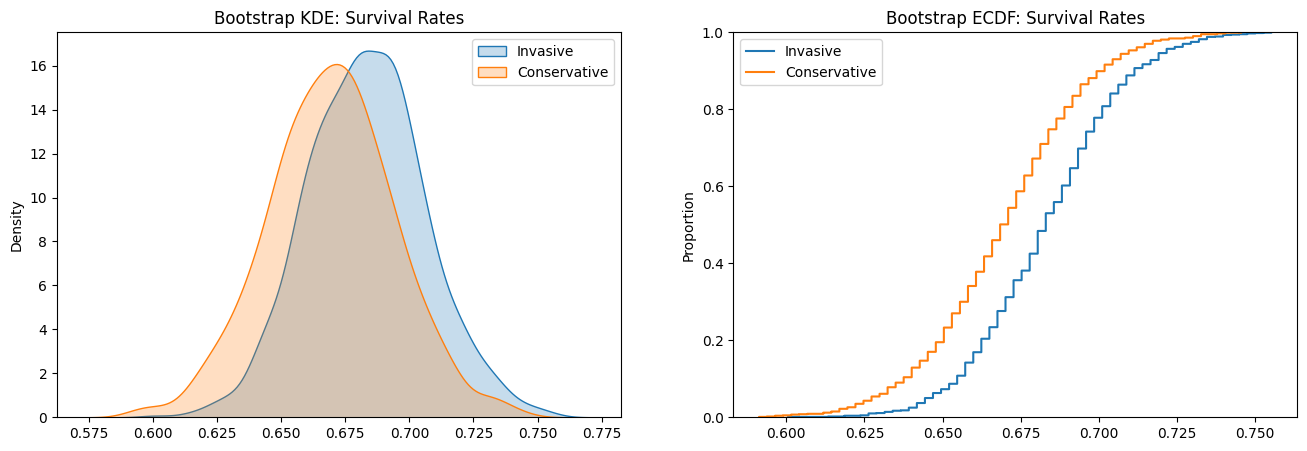

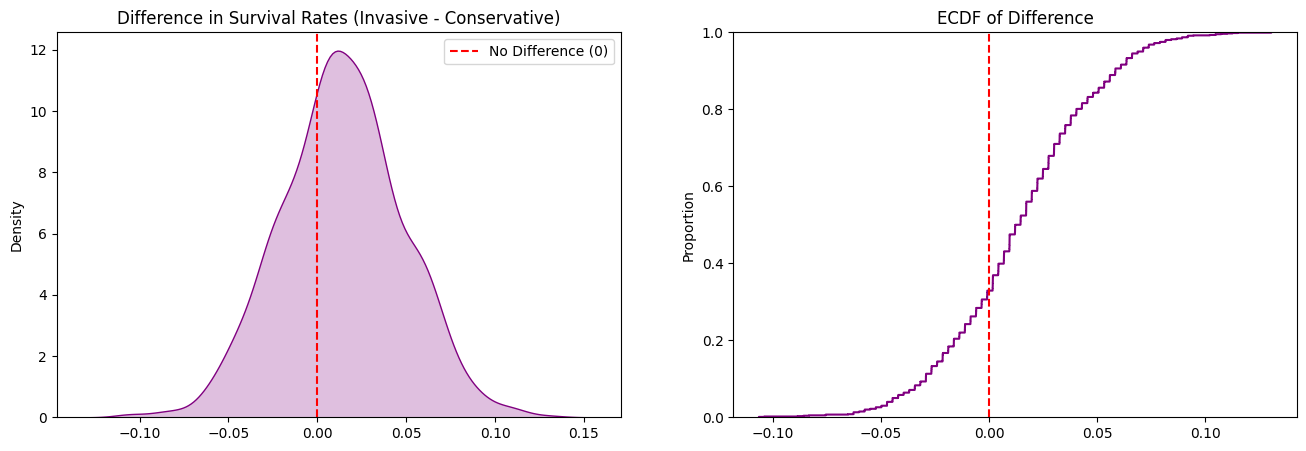

In [30]:
est1, est2, diffs = simulate(data_invasive, data_conservative, stat_mean, S=1000)

Based on the difference plot, the red line at zero falls right inside the purple distribution, which means it's totally possible that the Invasive strategy doesn't actually do anything different than the Conservative one. Since we can't prove that surgery saves more lives than just taking meds, we definitely can't call this an effective intervention. It doesn't make sense to put patients through the risks and costs of surgery when the conservative option basically gets the same results. Basically, the stats show that any benefit we saw is likely just random noise, so the extra risk just isn't worth it.

### Exercise 4: Prediction Uncertainty
- Pick a dataset and two continuous variables.
- Recall the LCLS estimator:
$$
\hat{y}(z) =  \frac{ \frac{1}{N} \sum_{i=1}^N y_i \times \frac{1}{h}k\left( \frac{z - x_i}{h} \right)}{ \frac{1}{N} \sum_{i=1}^N \frac{1}{h} k\left( \frac{z - x_i}{h} \right)}
$$
with the Epanechnikov kernel and the standard plug-in bandwidth for $h$
- Compute and plot this line for 30 bootstrap samples. Notice where there is a lot of variation in the predictions, versus little variation in the predictions.
- Now, for any $z$, we can bootstrap a distribution of predictions using the above formula. Do this at the 25th percentile, median, and 75th percentile of $X$, and make KDE plots of your results.
- Now, pick a grid for $z$: Obvious choices are all of the unique values in the data, or an equally spaced grid from the minimum value to the maximum value. For each $z$, bootstrap a sample of predictions and compute the .05 and .95 quantiles. Plot these error curves along with your LCLS estimate. Where are your predictions "tight"/reliable? Where are they highly variable/unreliable?